<a href="https://www.kaggle.com/code/omborse771924/student-social-media-mental-health-impact-eda?scriptVersionId=324825166" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivasingh4945/student-social-media-and-mental-health-impact/Student Social Media And Mental Health Impact.csv


## Dataset Load

In [2]:
df=pd.read_csv('/kaggle/input/datasets/shivasingh4945/student-social-media-and-mental-health-impact/Student Social Media And Mental Health Impact.csv')

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
df.tail()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7
4999,19,Male,China,Undergraduate,WeChat,Entertainment,5.4,177,1.2,1.5,6.3,High,6.1


In [5]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [6]:
df.isnull()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df.columns


Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

## EDA

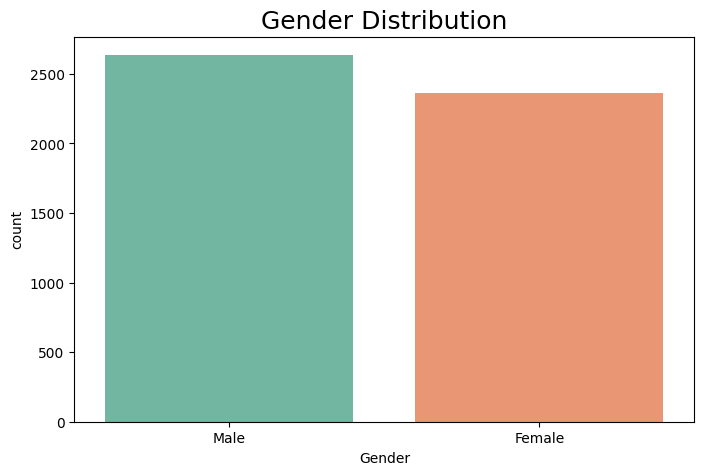

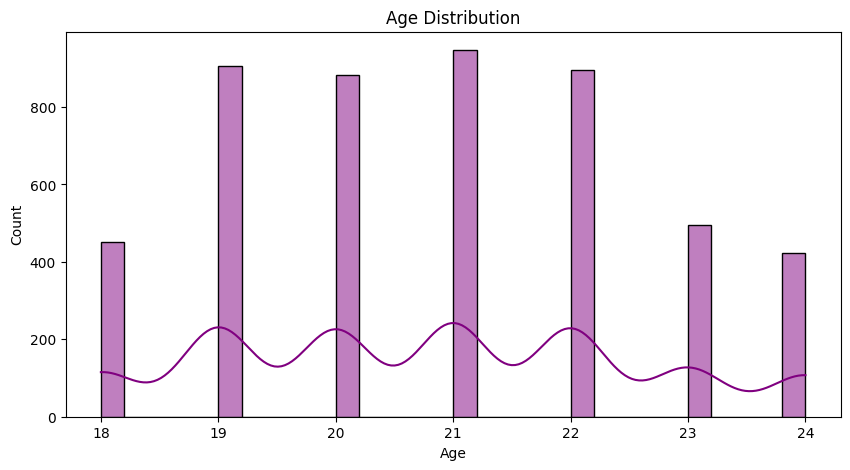

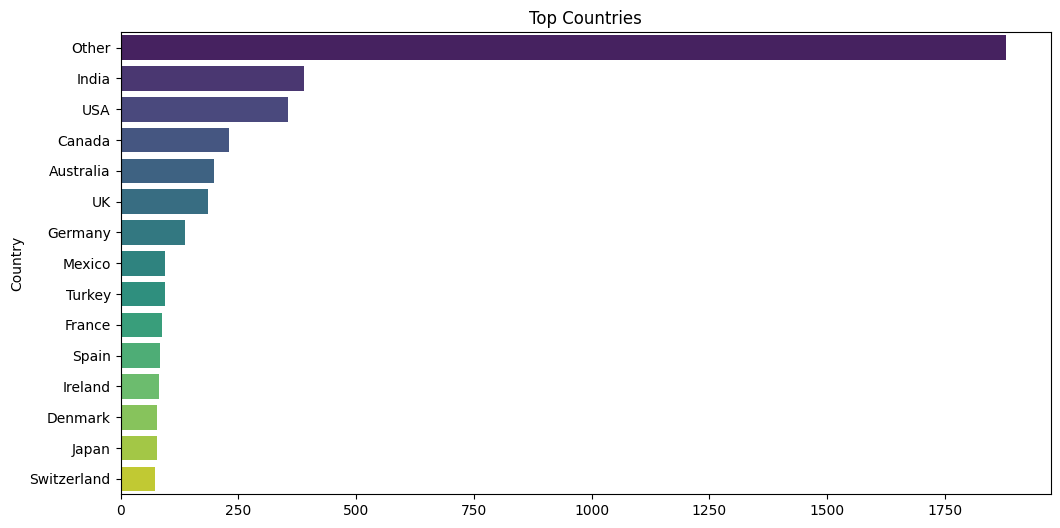

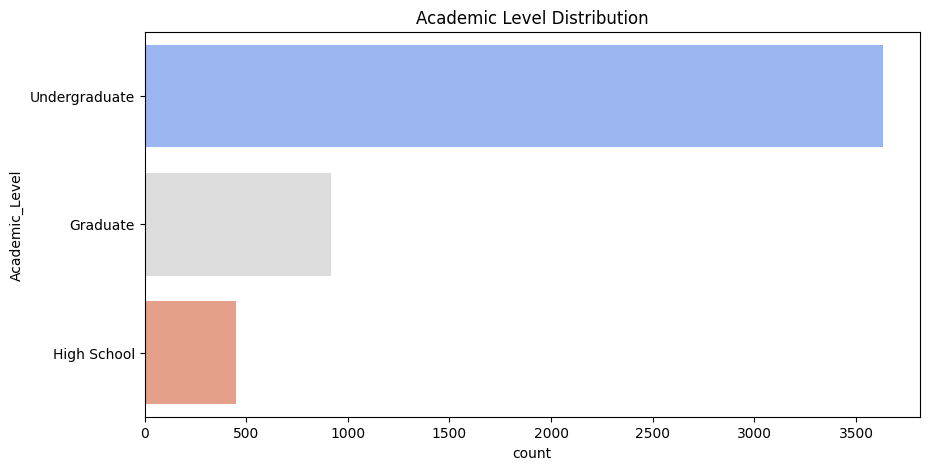

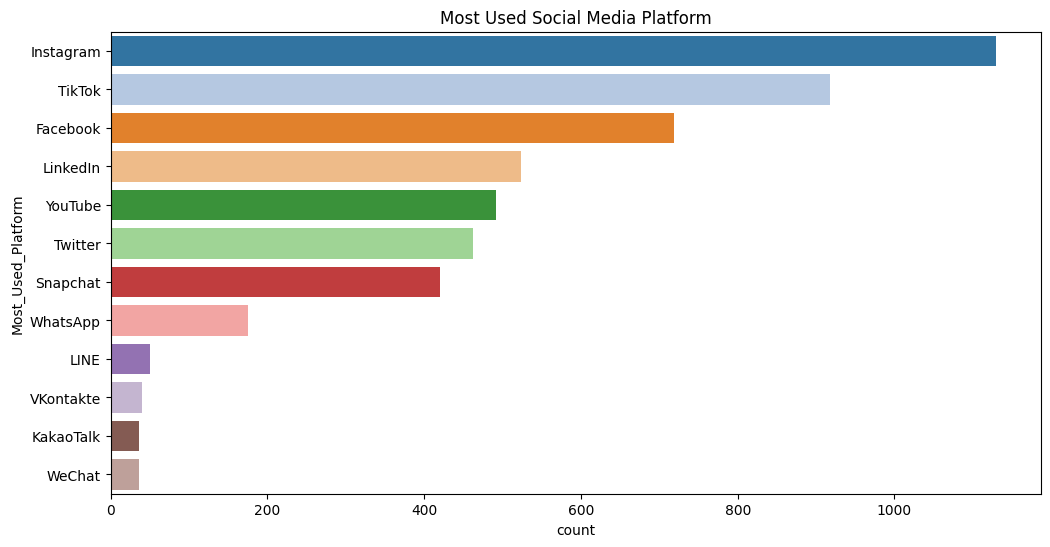

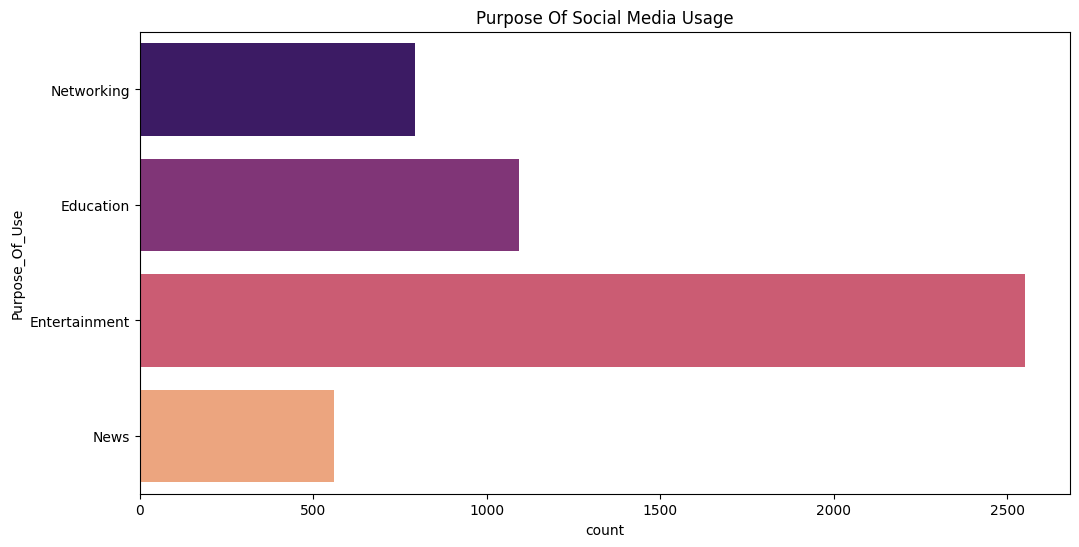

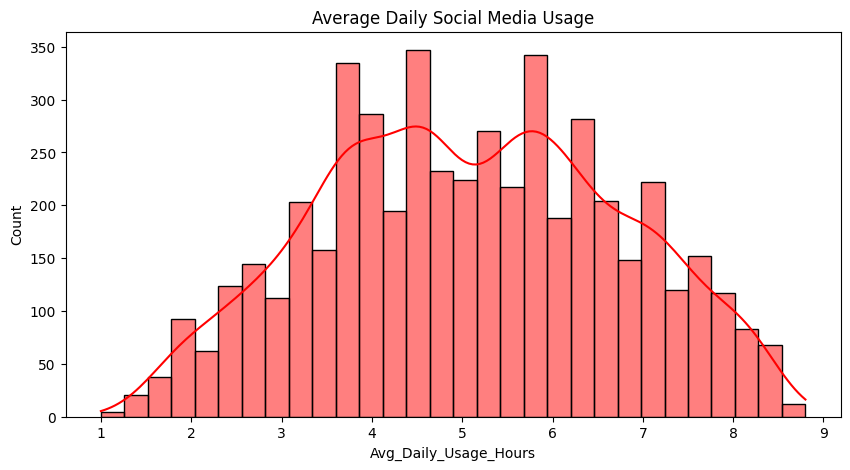

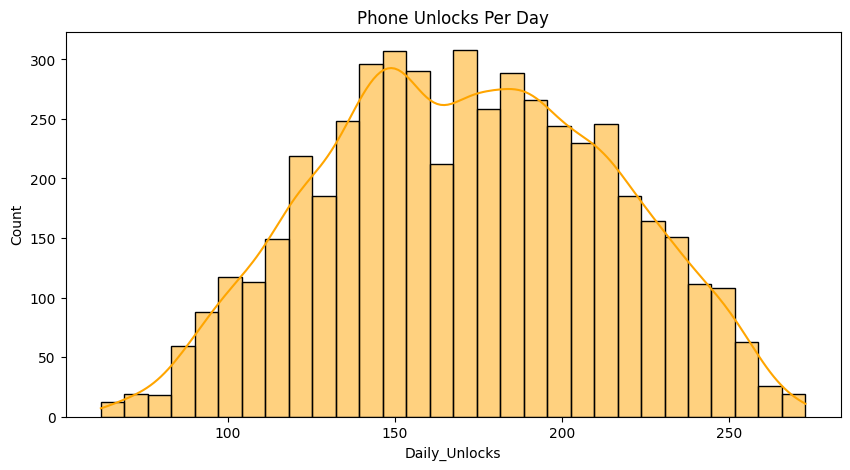

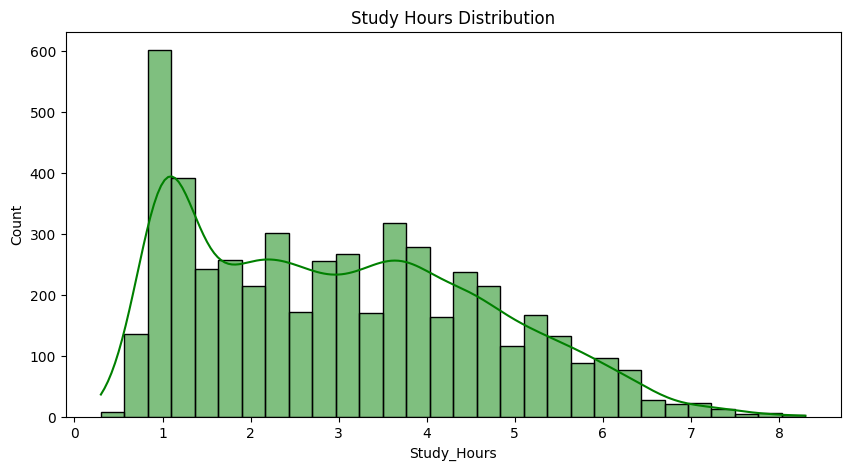

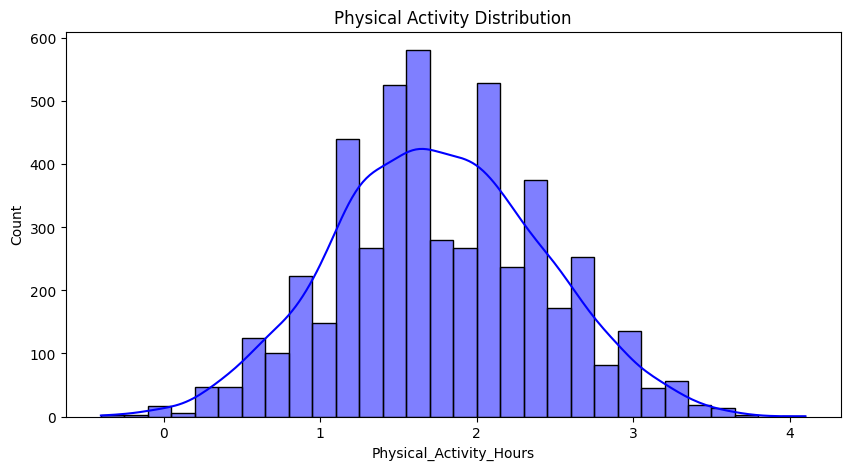

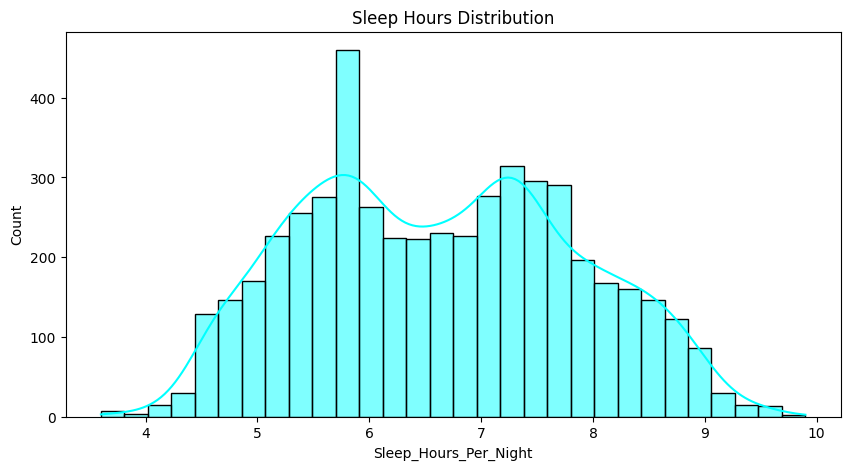

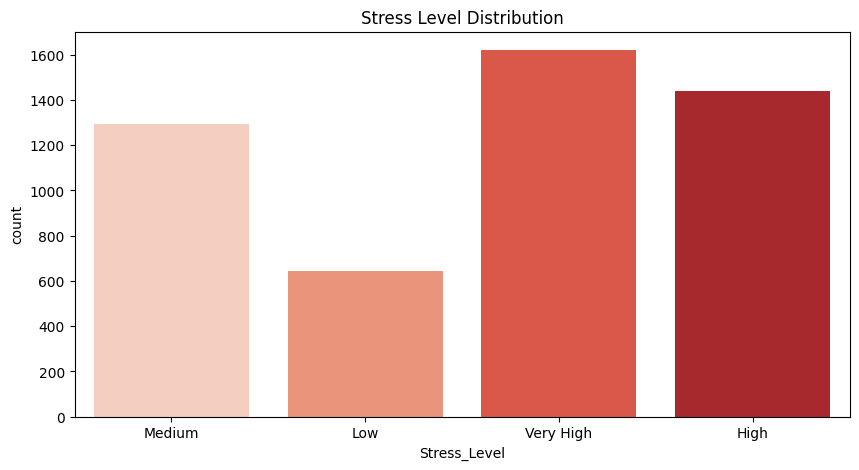

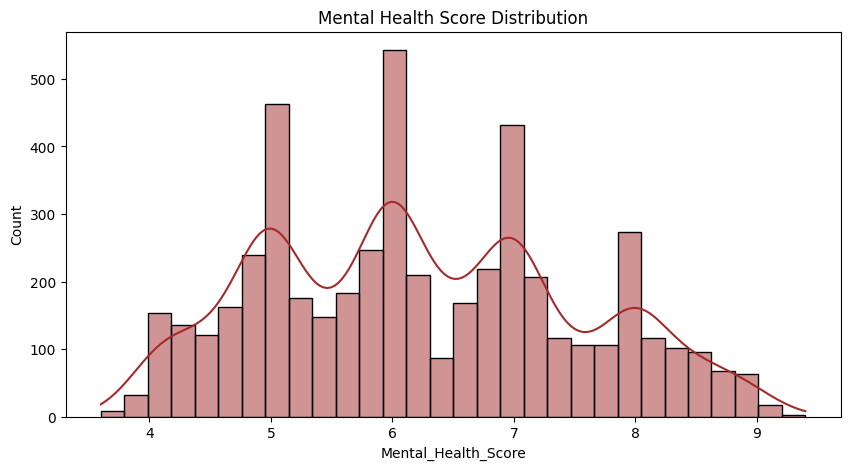

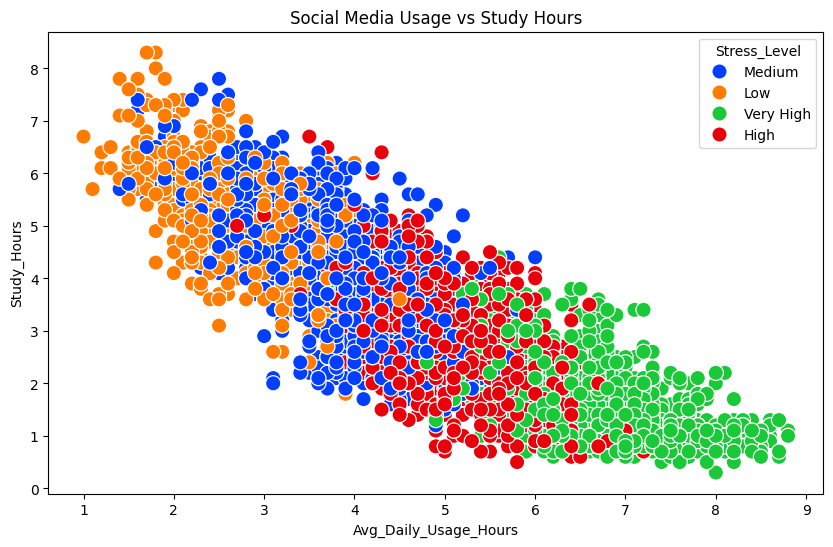

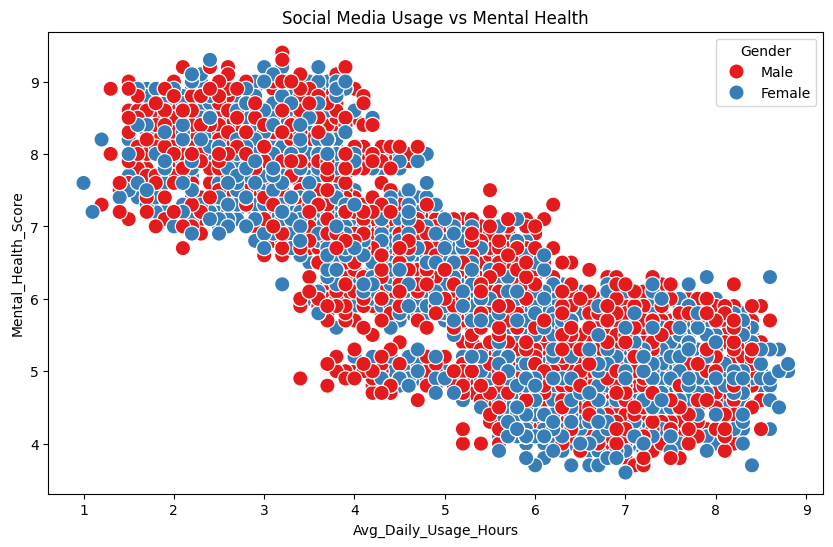

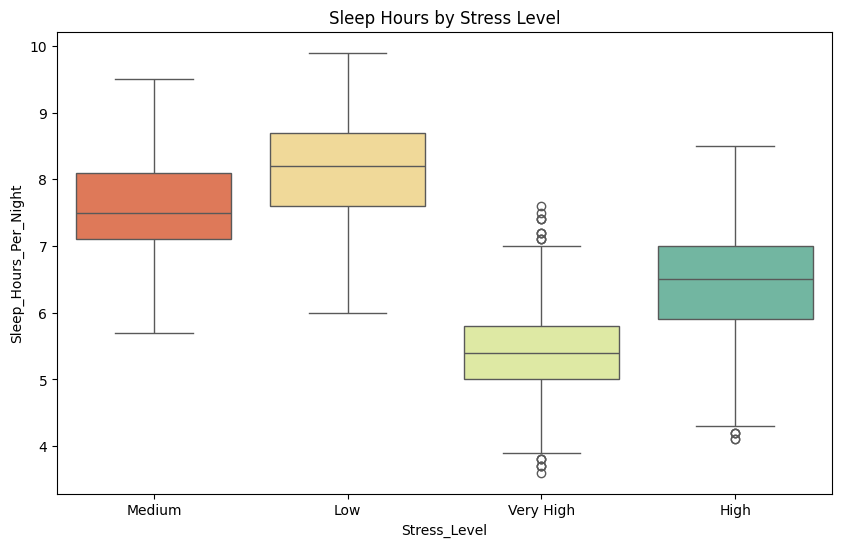

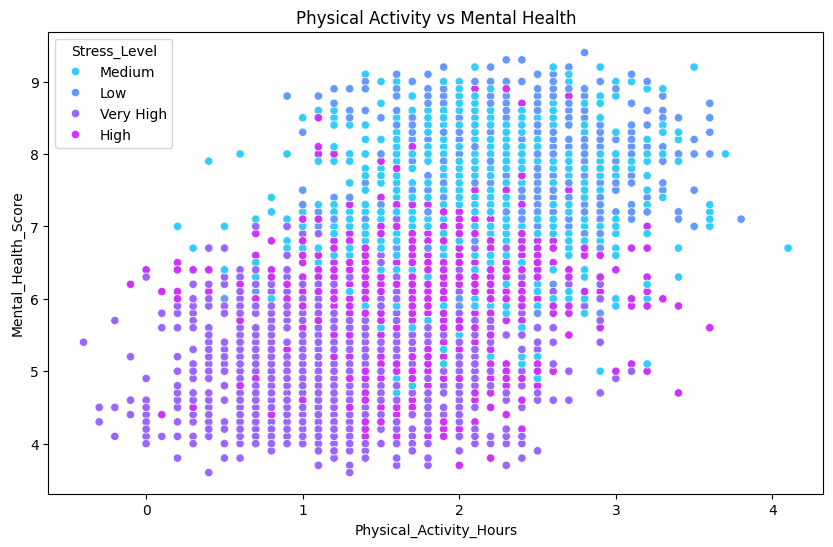

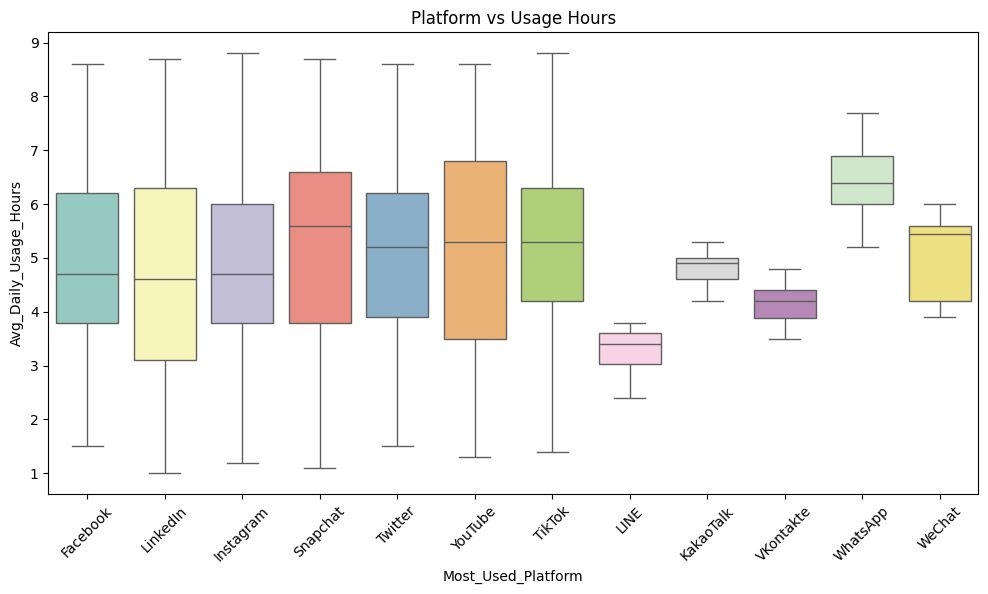

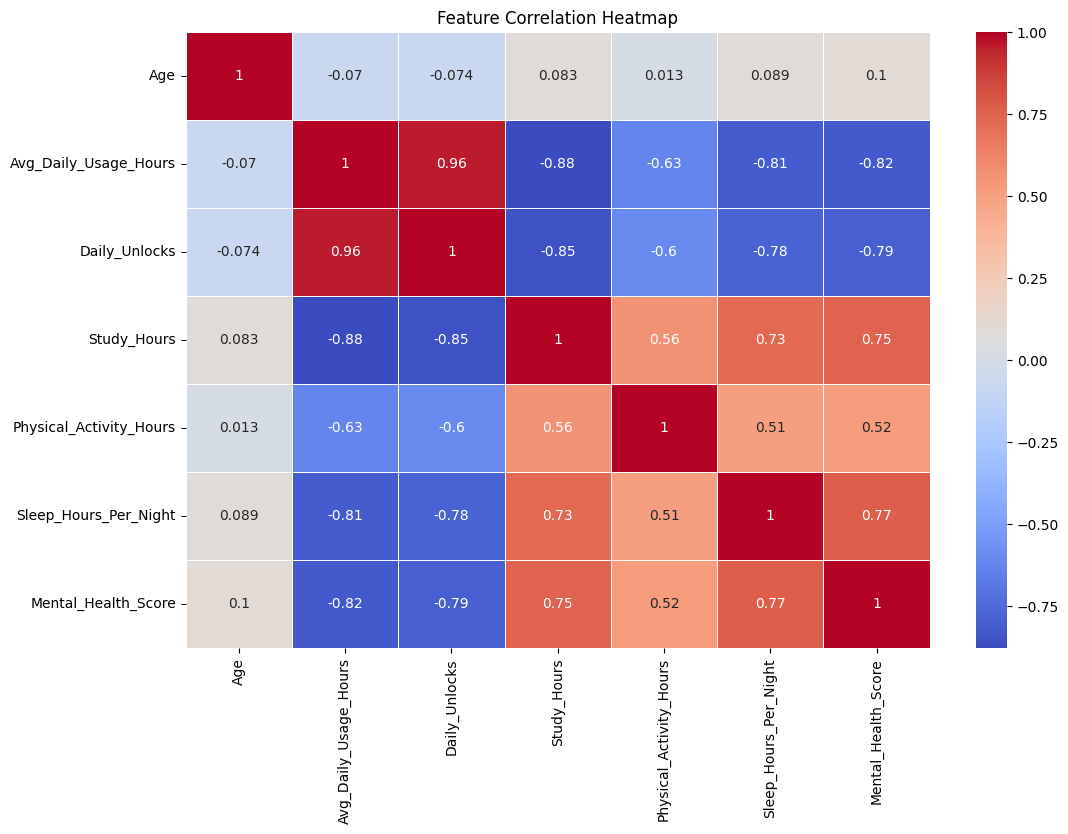

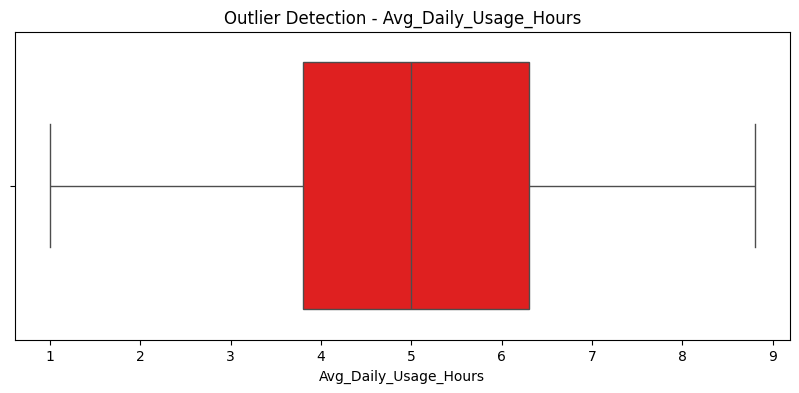

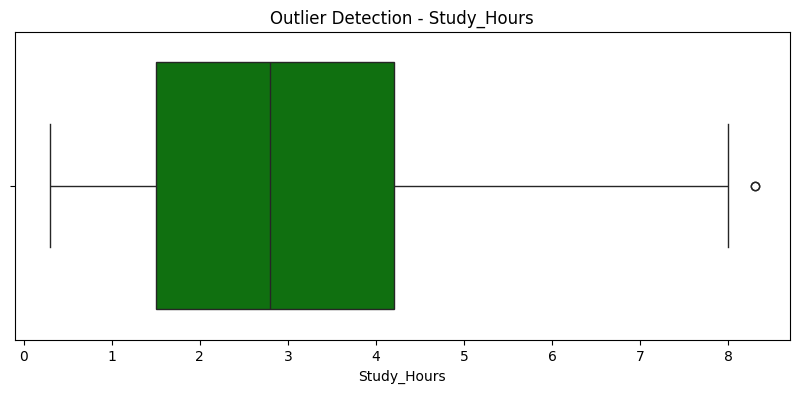

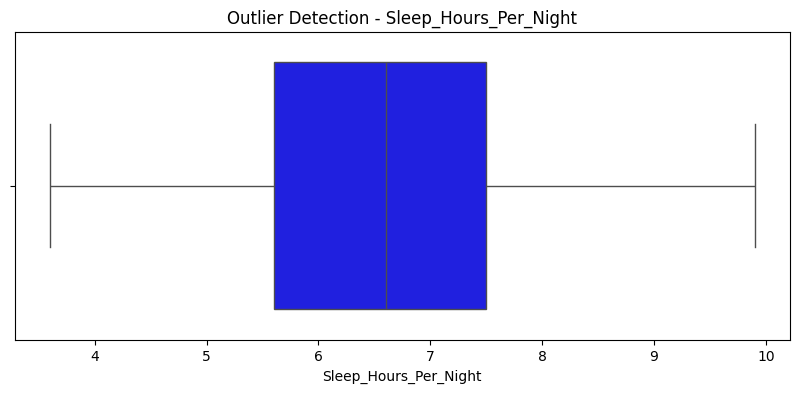

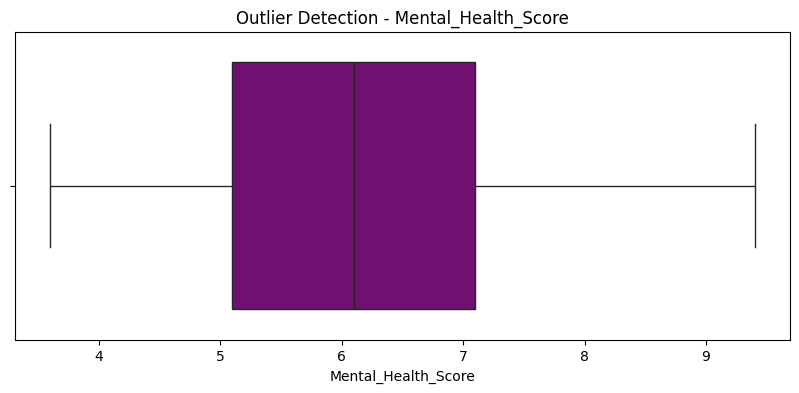

Detailed Visualization Completed Successfully!


In [10]:
# ============================================================
# 1. GENDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(

    x="Gender",

    data=df,

    palette="Set2"

)


plt.title(
    "Gender Distribution",
    fontsize=18
)

plt.show()





# ============================================================
# 2. AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))


sns.histplot(

    df["Age"],

    bins=30,

    kde=True,

    color="purple"

)



plt.title(

    "Age Distribution"

)


plt.show()








# ============================================================
# 3. COUNTRY DISTRIBUTION
# ============================================================


country_count = (

df["Country"]
.value_counts()
.head(15)

)


plt.figure(figsize=(12,6))


sns.barplot(

    x=country_count.values,

    y=country_count.index,

    palette="viridis"

)


plt.title(

    "Top Countries"

)


plt.show()







# ============================================================
# 4. ACADEMIC LEVEL
# ============================================================


plt.figure(figsize=(10,5))


sns.countplot(

    y="Academic_Level",

    data=df,

    palette="coolwarm"

)


plt.title(

    "Academic Level Distribution"

)


plt.show()








# ============================================================
# 5. MOST USED PLATFORM
# ============================================================


plt.figure(figsize=(12,6))


sns.countplot(

    y="Most_Used_Platform",

    data=df,

    order=df["Most_Used_Platform"].value_counts().index,

    palette="tab20"

)



plt.title(

    "Most Used Social Media Platform"

)



plt.show()









# ============================================================
# 6. PURPOSE OF USE
# ============================================================


plt.figure(figsize=(12,6))


sns.countplot(

    y="Purpose_Of_Use",

    data=df,

    palette="magma"

)


plt.title(

    "Purpose Of Social Media Usage"

)


plt.show()








# ============================================================
# 7. DAILY USAGE HOURS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Avg_Daily_Usage_Hours"],

    bins=30,

    kde=True,

    color="red"

)


plt.title(

    "Average Daily Social Media Usage"

)


plt.show()









# ============================================================
# 8. DAILY UNLOCKS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Daily_Unlocks"],

    bins=30,

    kde=True,

    color="orange"

)


plt.title(

    "Phone Unlocks Per Day"

)


plt.show()








# ============================================================
# 9. STUDY HOURS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Study_Hours"],

    bins=30,

    kde=True,

    color="green"

)



plt.title(

    "Study Hours Distribution"

)



plt.show()








# ============================================================
# 10. PHYSICAL ACTIVITY HOURS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Physical_Activity_Hours"],

    bins=30,

    kde=True,

    color="blue"

)



plt.title(

    "Physical Activity Distribution"

)


plt.show()








# ============================================================
# 11. SLEEP HOURS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Sleep_Hours_Per_Night"],

    bins=30,

    kde=True,

    color="cyan"

)


plt.title(

    "Sleep Hours Distribution"

)


plt.show()









# ============================================================
# 12. STRESS LEVEL
# ============================================================


plt.figure(figsize=(10,5))


sns.countplot(

    x="Stress_Level",

    data=df,

    palette="Reds"

)


plt.title(

    "Stress Level Distribution"

)


plt.show()








# ============================================================
# 13. MENTAL HEALTH SCORE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Mental_Health_Score"],

    bins=30,

    kde=True,

    color="brown"

)


plt.title(

    "Mental Health Score Distribution"

)


plt.show()









# ============================================================
# 14. SOCIAL MEDIA VS STUDY HOURS
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

    x="Avg_Daily_Usage_Hours",

    y="Study_Hours",

    hue="Stress_Level",

    data=df,

    palette="bright",

    s=120

)


plt.title(

    "Social Media Usage vs Study Hours"

)


plt.show()









# ============================================================
# 15. USAGE VS MENTAL HEALTH
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

    x="Avg_Daily_Usage_Hours",

    y="Mental_Health_Score",

    hue="Gender",

    data=df,

    palette="Set1",

    s=120

)


plt.title(

    "Social Media Usage vs Mental Health"

)


plt.show()








# ============================================================
# 16. SLEEP VS STRESS
# ============================================================


plt.figure(figsize=(10,6))


sns.boxplot(

    x="Stress_Level",

    y="Sleep_Hours_Per_Night",

    data=df,

    palette="Spectral"

)



plt.title(

    "Sleep Hours by Stress Level"

)


plt.show()









# ============================================================
# 17. PHYSICAL ACTIVITY VS MENTAL HEALTH
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

    x="Physical_Activity_Hours",

    y="Mental_Health_Score",

    hue="Stress_Level",

    data=df,

    palette="cool"

)



plt.title(

    "Physical Activity vs Mental Health"

)



plt.show()









# ============================================================
# 18. PLATFORM VS DAILY USAGE
# ============================================================


plt.figure(figsize=(12,6))


sns.boxplot(

    x="Most_Used_Platform",

    y="Avg_Daily_Usage_Hours",

    data=df,

    palette="Set3"

)


plt.xticks(rotation=45)



plt.title(

    "Platform vs Usage Hours"

)



plt.show()









# ============================================================
# 19. CORRELATION HEATMAP
# ============================================================


numeric_df = df.select_dtypes(

    include=np.number

)


plt.figure(figsize=(12,8))


sns.heatmap(

    numeric_df.corr(),

    annot=True,

    cmap="coolwarm",

    linewidth=0.5

)


plt.title(

    "Feature Correlation Heatmap"

)


plt.show()









# ============================================================
# 20. OUTLIER DETECTION
# ============================================================


features=[

"Avg_Daily_Usage_Hours",

"Study_Hours",

"Sleep_Hours_Per_Night",

"Mental_Health_Score"

]


colors=[

"red",

"green",

"blue",

"purple"

]


for feature,color in zip(features,colors):


    plt.figure(figsize=(10,4))


    sns.boxplot(

        x=df[feature],

        color=color

    )


    plt.title(

        f"Outlier Detection - {feature}"

    )


    plt.show()






# ============================================================
# FINISH
# ============================================================


print(
    "Detailed Visualization Completed Successfully!"
)



## Features Engineering

Stress_Level
Very High    1621
High         1440
Medium       1295
Low           644
Name: count, dtype: int64

Logistic Regression
Accuracy: 0.748
              precision    recall  f1-score   support

        High       0.69      0.70      0.69       288
         Low       0.75      0.65      0.70       129
      Medium       0.66      0.67      0.67       259
   Very High       0.87      0.89      0.88       324

    accuracy                           0.75      1000
   macro avg       0.74      0.73      0.73      1000
weighted avg       0.75      0.75      0.75      1000


Decision Tree
Accuracy: 0.797
              precision    recall  f1-score   support

        High       0.73      0.75      0.74       288
         Low       0.79      0.77      0.78       129
      Medium       0.75      0.73      0.74       259
   Very High       0.89      0.90      0.90       324

    accuracy                           0.80      1000
   macro avg       0.79      0.79      0.79      1000
weight

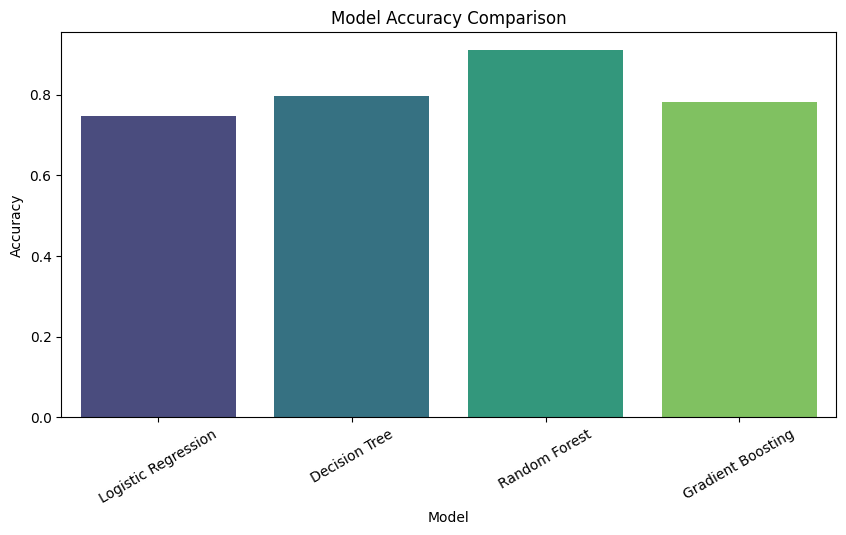

Best Model: Random Forest


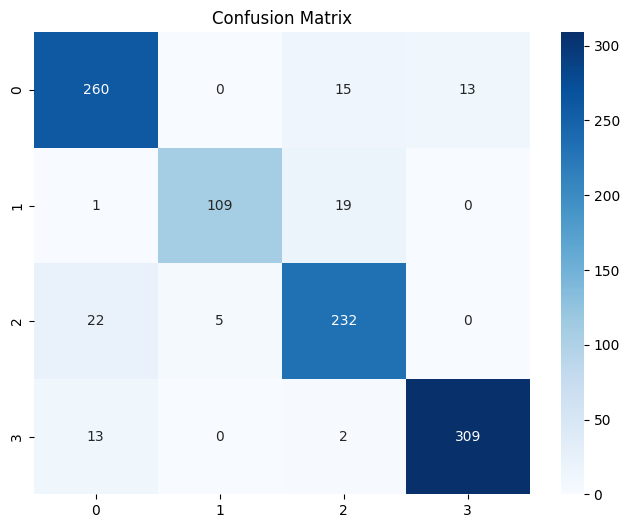

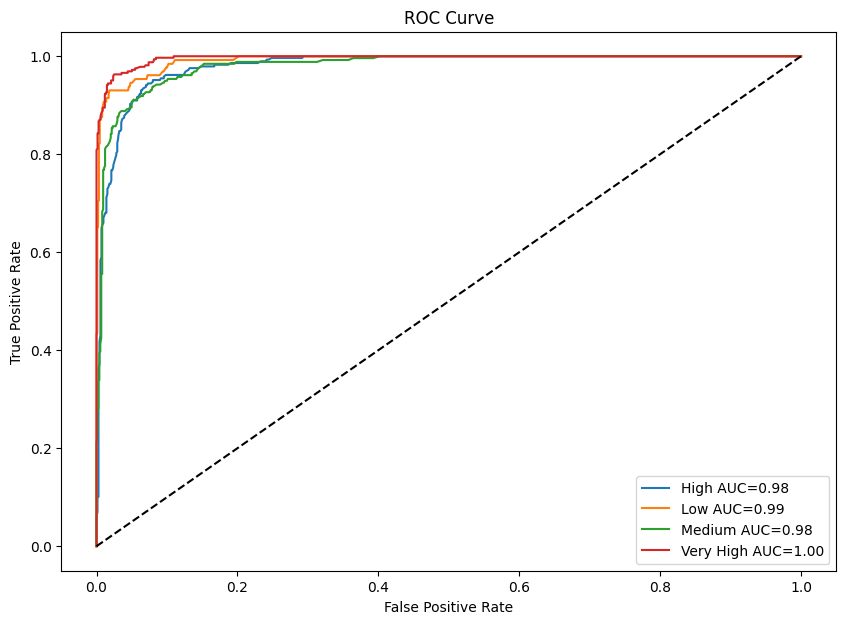

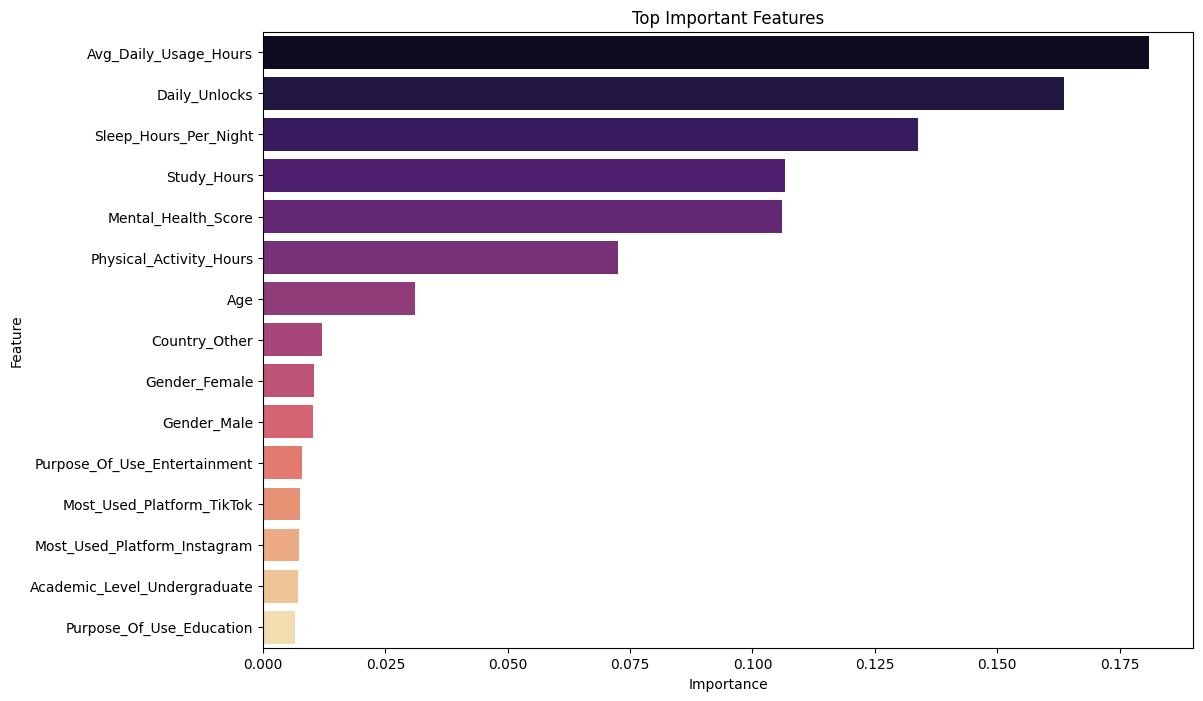


FINAL MODEL RESULTS
Logistic Regression : 0.748
Decision Tree : 0.797
Random Forest : 0.91
Gradient Boosting : 0.781
Best Model: Random Forest
Best Accuracy: 0.91


In [11]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    label_binarize
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)




# ============================================================
# FEATURES & TARGET
# ============================================================

X = df.drop(
    "Stress_Level",
    axis=1
)


y = df[
    "Stress_Level"
]



print(
    y.value_counts()
)




# ============================================================
# TRAIN TEST SPLIT
# ============================================================
# before preprocessing = prevents leakage


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)




# ============================================================
# IDENTIFY NUMERICAL & CATEGORICAL
# ============================================================


numeric_cols = X.select_dtypes(
    include=np.number
).columns


categorical_cols = X.select_dtypes(
    include="object"
).columns




# ============================================================
# NUMERICAL PIPELINE
# ============================================================

numeric_pipeline = Pipeline(

steps=[

(
"imputer",

SimpleImputer(
strategy="median"
)

),


(
"scaler",

StandardScaler()

)


]

)




# ============================================================
# CATEGORICAL PIPELINE
# ============================================================


categorical_pipeline = Pipeline(

steps=[

(
"imputer",

SimpleImputer(
strategy="most_frequent"
)

),


(
"encoder",

OneHotEncoder(
handle_unknown="ignore"
)

)


]

)




# ============================================================
# COLUMN TRANSFORMER
# ============================================================


preprocessor = ColumnTransformer(

transformers=[


(
"num",

numeric_pipeline,

numeric_cols

),



(
"cat",

categorical_pipeline,

categorical_cols

)


]

)




# ============================================================
# MODELS
# ============================================================


models={


"Logistic Regression":

LogisticRegression(
max_iter=1000
),



"Decision Tree":

DecisionTreeClassifier(
random_state=42
),



"Random Forest":

RandomForestClassifier(

n_estimators=300,

random_state=42

),



"Gradient Boosting":

GradientBoostingClassifier(

random_state=42

)

}




results={}

trained_models={}




# ============================================================
# TRAIN MODELS
# ============================================================


for name,model in models.items():


    print("\n==============================")
    print(name)
    print("==============================")


    pipe = Pipeline(

        steps=[


        (
        "preprocessor",
        preprocessor
        ),


        (
        "classifier",
        model
        )


        ]

    )



    pipe.fit(

        X_train,

        y_train

    )



    prediction = pipe.predict(

        X_test

    )



    accuracy = accuracy_score(

        y_test,

        prediction

    )



    results[name]=accuracy

    trained_models[name]=pipe



    print(

        "Accuracy:",

        round(accuracy,4)

    )



    print(

        classification_report(

            y_test,

            prediction

        )

    )





# ============================================================
# ACCURACY COMPARISON
# ============================================================


accuracy_df=pd.DataFrame({

"Model":results.keys(),

"Accuracy":results.values()

})



plt.figure(figsize=(10,5))


sns.barplot(

data=accuracy_df,

x="Model",

y="Accuracy",

palette="viridis"

)



plt.title(

"Model Accuracy Comparison"

)



plt.xticks(rotation=30)


plt.show()






# ============================================================
# BEST MODEL
# ============================================================

best_name=max(

results,

key=results.get

)



best_model=trained_models[

best_name

]


print(

"Best Model:",

best_name

)





# ============================================================
# CONFUSION MATRIX
# ============================================================


best_pred=best_model.predict(

X_test

)



plt.figure(figsize=(8,6))


sns.heatmap(

confusion_matrix(

y_test,

best_pred

),

annot=True,

fmt="d",

cmap="Blues"

)


plt.title(

"Confusion Matrix"

)


plt.show()






# ============================================================
# MULTICLASS ROC CURVE
# ============================================================


classes=np.unique(y)



y_bin=label_binarize(

y_test,

classes=classes

)



prob=best_model.predict_proba(

X_test

)



plt.figure(figsize=(10,7))



for i in range(len(classes)):


    fpr,tpr,_=roc_curve(

    y_bin[:,i],

    prob[:,i]

    )



    auc=roc_auc_score(

    y_bin[:,i],

    prob[:,i]

    )



    plt.plot(

    fpr,

    tpr,

    label=f"{classes[i]} AUC={auc:.2f}"

    )





plt.plot(

[0,1],

[0,1],

"k--"

)



plt.xlabel(

"False Positive Rate"

)


plt.ylabel(

"True Positive Rate"

)



plt.title(

"ROC Curve"

)


plt.legend()


plt.show()





# ============================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================

rf_model = trained_models[
    "Random Forest"
]


feature_names = (
    list(numeric_cols)
    +
    list(
        rf_model.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .named_steps["encoder"]
        .get_feature_names_out(
            categorical_cols
        )
    )
)



importance = pd.DataFrame({

"Feature":feature_names,

"Importance":
rf_model.named_steps["classifier"]
.feature_importances_

})



importance=importance.sort_values(

"Importance",

ascending=False

)



plt.figure(figsize=(12,8))


sns.barplot(

data=importance.head(15),

x="Importance",

y="Feature",

palette="magma"

)


plt.title(

"Top Important Features"

)


plt.show()







# ============================================================
# FINAL RESULTS
# ============================================================


print("\nFINAL MODEL RESULTS")

print("======================")


for model,score in results.items():

    print(

    model,

    ":",

    round(score,4)

    )



print("======================")


print(

"Best Model:",

best_name

)


print(

"Best Accuracy:",

round(max(results.values()),4)

)

## Thank You..........Please Upvote